# Fit a Gaussian family

Fit a Gaussian regression with {class}`LieselVI <liesel.optim.LieselVI>`, first on all observations and then with mini-batches and held-out test data. The optimizer adjusts an approximate posterior's parameters rather than the target parameters directly.

## Imports

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

In [2]:
pd.options.display.float_format = "{:.3f}".format

## Simulate data

The response `y` and design matrix `X` share observation axis 0, so the same row split applies to both.

In [3]:
rng = np.random.default_rng(202407)

n = 240
x = rng.uniform(-2.0, 2.0, size=n)
X = np.column_stack([np.ones(n), x])

beta_true = np.array([0.7, -1.4])
sigma_true = 0.6
y = X @ beta_true + rng.normal(scale=sigma_true, size=n)

In [4]:
pd.Series(
    {
        "n": n,
        "beta_true": beta_true.tolist(),
        "sigma_true": sigma_true,
        "y_mean": float(y.mean()),
    },
    name="Value",
).to_frame()

,Value
n,240
beta_true,"[0.7, -1.4]"
sigma_true,0.600
y_mean,0.585


In [5]:
data = pd.DataFrame({"x": x, "y": y})

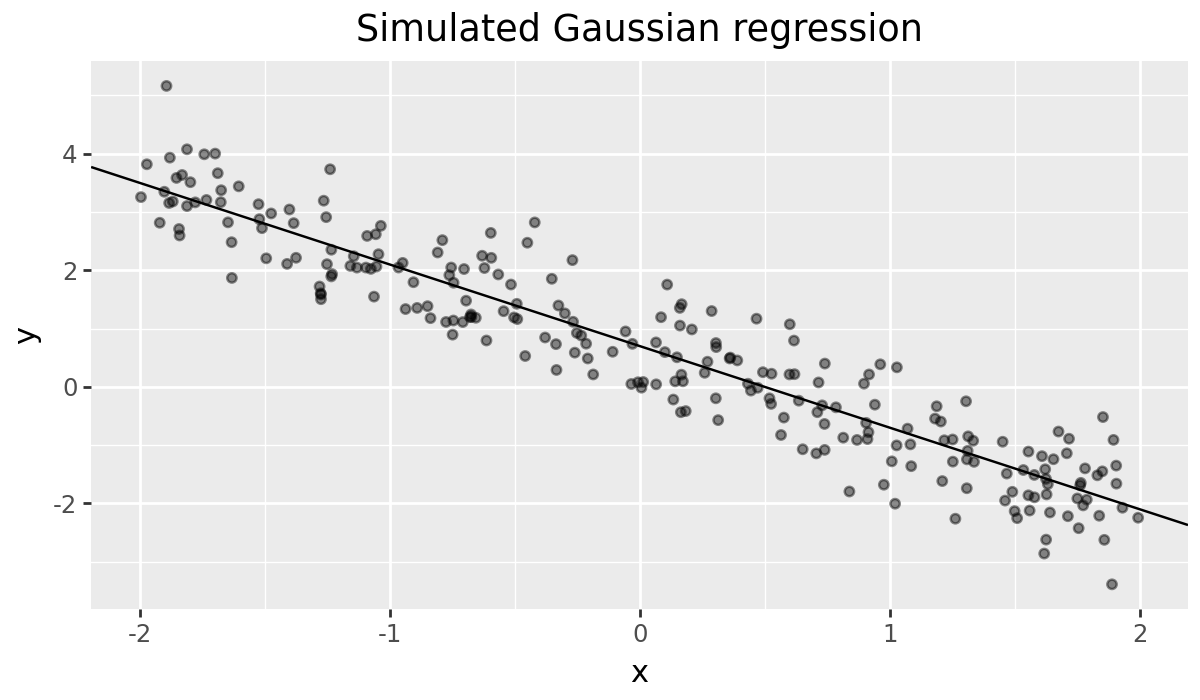

In [6]:
(
    p9.ggplot(data, p9.aes("x", "y"))
    + p9.geom_point(alpha=0.45, size=1.4)
    + p9.geom_abline(intercept=beta_true[0], slope=beta_true[1])
    + p9.labs(title="Simulated Gaussian regression")
    + p9.theme(figure_size=(6, 3.5))
)

## Build the model

The model has two target parameters: a vector of regression coefficients `beta` and the unconstrained scale parameter `log_sigma`. The standard deviation used in the likelihood is `sigma = exp(log_sigma)`.

In [7]:
X_jax = jnp.asarray(X)
y_jax = jnp.asarray(y)

beta = lsl.Var.new_param(
    jnp.zeros(X_jax.shape[1]),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="beta",
)

log_sigma = lsl.Var.new_param(
    jnp.array(0.0),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="log_sigma",
)
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")

X_var = lsl.Var.new_obs(X_jax, name="X")
mu = lsl.Var.new_calc(
    lambda X, beta: X @ beta,
    X_var,
    beta,
    name="mu",
)
y_var = lsl.Var.new_obs(
    y_jax,
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)

model = lsl.Model(y_var)

In [8]:
pd.Series(
    {
        "parameters": list(model.parameters),
        "observed": list(model.observed),
    },
    name="Value",
).to_frame()

,Value
parameters,"[log_sigma, beta]"
observed,"[X, y]"


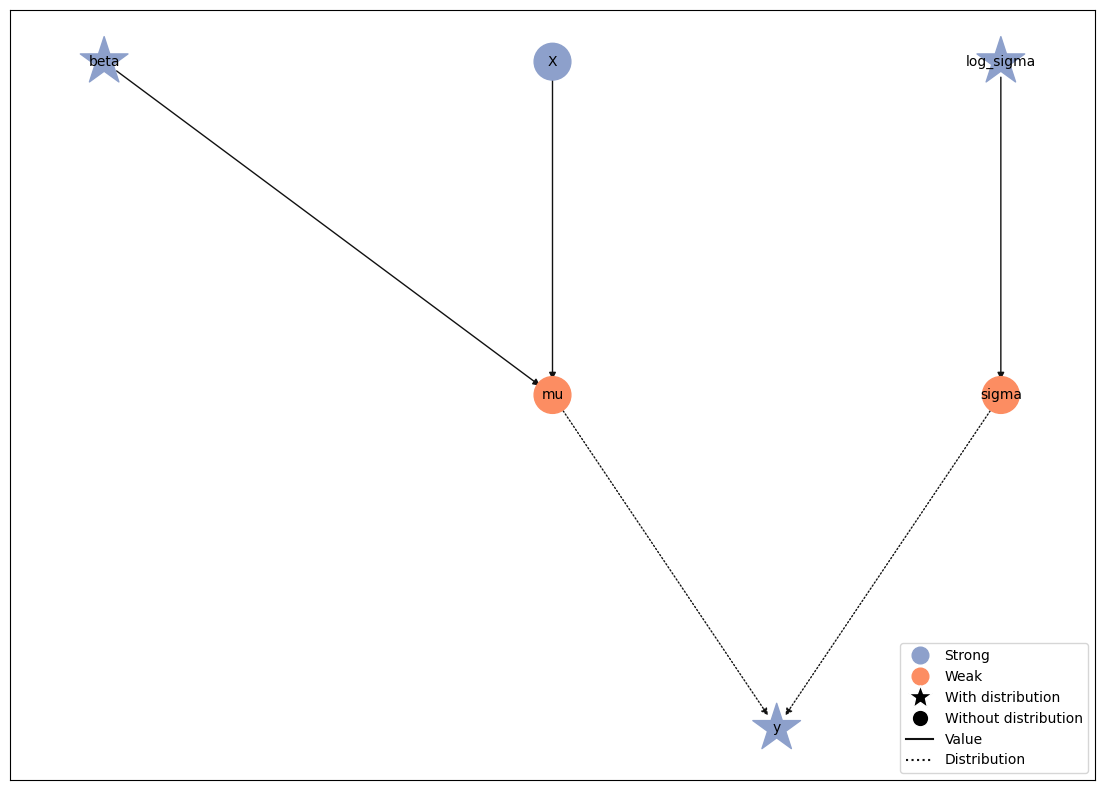

In [9]:
model.plot()

## Fit a diagonal Gaussian

{meth}`NegElboLoss.mvn_diag() <liesel.optim.NegElboLoss.mvn_diag>` covers all target parameters with independent Gaussian components. Here each epoch is one full-data Adam step, so the learning-rate schedule also advances once per epoch.

We choose initial SD `0.2`; the default `0.1` is a heuristic in model units. See {ref}`vi-initial-scale` for choosing a scale.

In [10]:
loss_full = opt.NegElboLoss.mvn_diag(
    model,
    nsamples=5,
    scale=True,
    scale_diag=0.2,
)

full_schedule = optax.exponential_decay(
    init_value=2e-2,
    transition_steps=60,
    decay_rate=0.95,
    end_value=1e-3,
)

full_engine = opt.LieselVI(
    model,
    loss_monitor=opt.EmaTrainLossMonitor(effective_window=20.0),
    loss=loss_full,
    optimizers=optax.adam(full_schedule),
    stopper=opt.Stopper(epochs=350, patience=60, rtol=1e-4),
    seed=11,
).build_engine()

In [11]:
pd.Series(
    {
        "q_parameters": list(loss_full.q.parameters),
        "batching": repr(full_engine.batches),
    },
    name="Value",
).to_frame()

,Value
q_parameters,"[(beta|log_sigma)_loc, h((beta|log_sigma)_scale)]"
batching,"Batches(axis_size=240, batch_size=240, default..."


In [12]:
result_full = full_engine.fit()

liesel.optim.engine - INFO - Initializing optimization at epoch 0


Initializing:   0%|          | 0/350 [00:00<?, ?it/s]

Train=2.234, Monitor=2.522:   3%|▎         | 10/350 [00:01<01:07,  5.01it/s]

Train=0.937, Monitor=0.944:  85%|████████▍ | 297/350 [00:02<00:00, 131.14it/s]

In [13]:
result_full

OptimResult(n_epochs=297, min_monitor_epoch=296, monitor_source='train_ema', duration=3.3s)

## Draw posterior samples

`approximate_joint_posterior()` binds the final iterate by default. Samples have the target's parameter names and shapes. Inspect the loss curve below and use the held-out check later to assess the fit.

In [14]:
posterior_full = loss_full.approximate_joint_posterior(result_full, at="final").sample(
    2_000, seed=jax.random.key(2024)
)

beta_samples = np.asarray(posterior_full["beta"])
sigma_samples = np.exp(np.asarray(posterior_full["log_sigma"]))

rows = [
    {
        "parameter": f"beta[{i}]",
        "mean": float(beta_samples[:, i].mean()),
        "sd": float(beta_samples[:, i].std()),
        "truth": float(truth),
    }
    for i, truth in enumerate(beta_true)
]
rows.append(
    {
        "parameter": "sigma",
        "mean": float(sigma_samples.mean()),
        "sd": float(sigma_samples.std()),
        "truth": float(sigma_true),
    }
)

In [15]:
pd.DataFrame(rows)

,parameter,mean,sd,truth
0,beta[0],0.661,0.042,0.700
1,beta[1],-1.413,0.047,-1.400
2,sigma,0.595,0.053,0.600


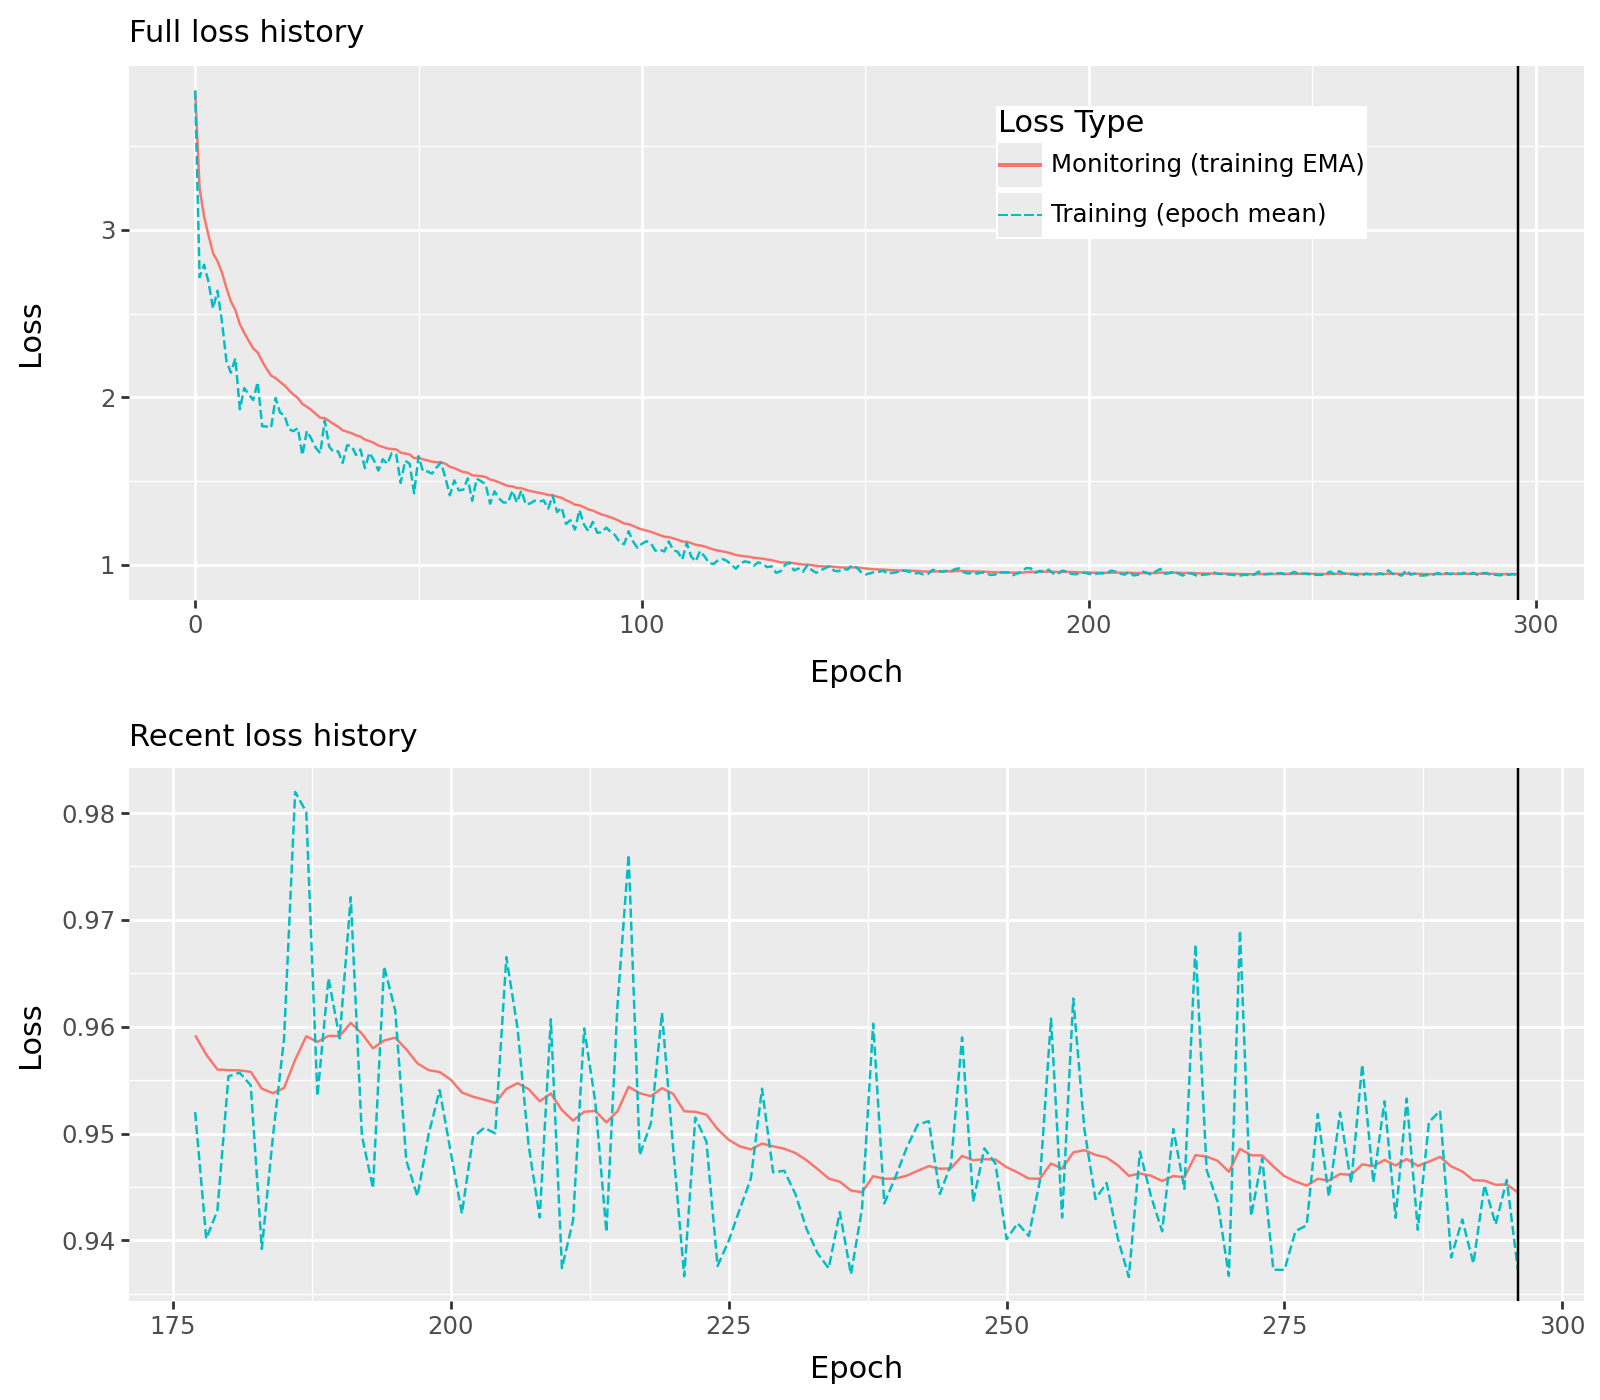

In [16]:
result_full.plot_loss_overview()

## Choose an entropy estimator

The ELBO combines expected target log likelihood and log prior with variational entropy:

$$
\mathrm{ELBO}=\mathbb{E}_{q}[\log p(y\mid\theta)+\log p(\theta)]+H(q).
$$

The default `entropy="auto"` uses analytic entropy where available, with Monte Carlo fallback. Set `entropy="mc"` on the loss to estimate all entropy terms by sampling. Either way, the target likelihood and prior still use random draws. See {class}`~liesel.optim.NegElboLoss` for conditional and custom families.

Target priors remain included. Extra priors on variational parameters are excluded by default; see {ref}`vi-q-prior-penalties`.

## Add a train/test split

ELBO losses do not support validation data. Reserve test rows for the final predictive check. The split seed selects those rows; the {class}`LieselVI <liesel.optim.LieselVI>` seed controls variational draws and batch shuffling.

In [17]:
split = opt.PositionSplit.from_model(
    model,
    position_keys=["X", "y"],
    test_axis_share=0.1,
    shuffle=True,
    seed=123,
)

In [18]:
pd.DataFrame(
    {
        "part": ["train", "validate", "test"],
        "n": [split.train_axis_size, split.validate_axis_size, split.test_axis_size],
    }
)

,part,n
0,train,216
1,validate,0
2,test,24


## Use mini-batches

Set `batch_size` and smooth the stochastic loss with an EMA span of 20 epoch equivalents. For the smoothing tradeoff, see {ref}`monitoring choices <vi-monitoring>`.

In [19]:
loss_mb = opt.NegElboLoss.mvn_diag(
    model,
    split=split,
    nsamples=3,
    scale=True,
    scale_diag=0.2,
)

mb_schedule = optax.exponential_decay(
    init_value=3e-2,
    transition_steps=60,
    decay_rate=0.95,
    end_value=1e-3,
)

mb_engine = opt.LieselVI(
    model,
    loss_monitor=opt.EmaTrainLossMonitor(effective_window=20.0),
    loss=loss_mb,
    batch_size=40,
    optimizers=optax.adam(mb_schedule),
    stopper=opt.Stopper(epochs=350, patience=50, rtol=1e-4),
    seed=22,
).build_engine()

In [20]:
pd.Series(
    {
        "batching": repr(mb_engine.batches),
        "loss_monitor": mb_engine.loss_monitor,
    },
    name="Value",
).to_frame()

,Value
batching,"Batches(axis_size=216, batch_size=40, default_..."
loss_monitor,EmaTrainLossMonitor(effective_window=20.0)


In [21]:
result_mb = mb_engine.fit()

liesel.optim.engine - INFO - Initializing optimization at epoch 0


Initializing:   0%|          | 0/350 [00:00<?, ?it/s]

Train=1.349, Monitor=1.649:   3%|▎         | 10/350 [00:01<01:00,  5.59it/s]

Train=0.965, Monitor=0.958:  34%|███▍      | 120/350 [00:01<00:03, 65.95it/s]

In [22]:
result_mb

OptimResult(n_epochs=120, min_monitor_epoch=70, monitor_source='train_ema', duration=2.2s)

In [23]:
posterior_mb = loss_mb.approximate_joint_posterior(result_mb, at="final").sample(
    2_000, seed=jax.random.key(2025)
)

beta_samples = np.asarray(posterior_mb["beta"])
sigma_samples = np.exp(np.asarray(posterior_mb["log_sigma"]))

rows = [
    {
        "parameter": f"beta[{i}]",
        "mean": float(beta_samples[:, i].mean()),
        "sd": float(beta_samples[:, i].std()),
        "truth": float(truth),
    }
    for i, truth in enumerate(beta_true)
]
rows.append(
    {
        "parameter": "sigma",
        "mean": float(sigma_samples.mean()),
        "sd": float(sigma_samples.std()),
        "truth": float(sigma_true),
    }
)

In [24]:
pd.DataFrame(rows)

,parameter,mean,sd,truth
0,beta[0],0.680,0.044,0.700
1,beta[1],-1.415,0.035,-1.400
2,sigma,0.594,0.029,0.600


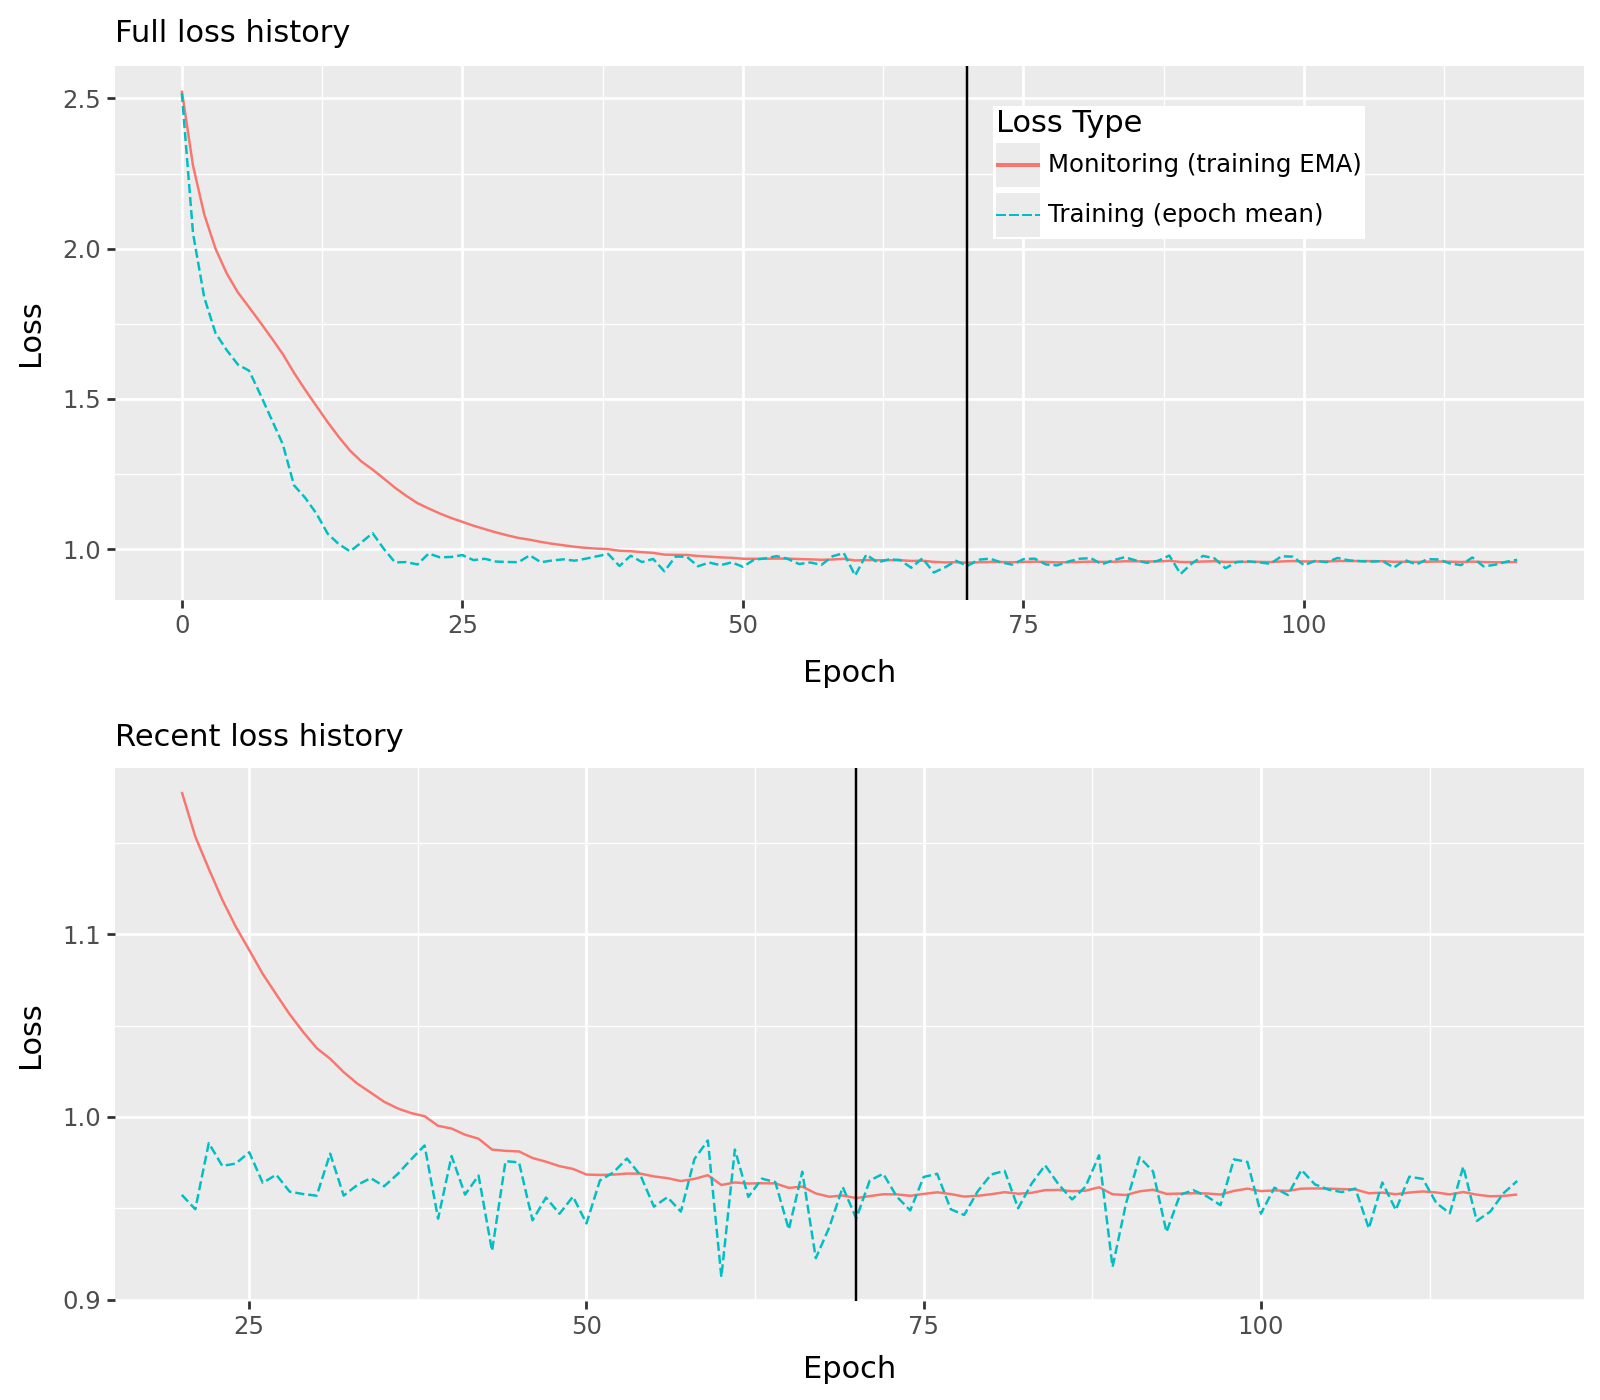

In [25]:
result_mb.plot_loss_overview()

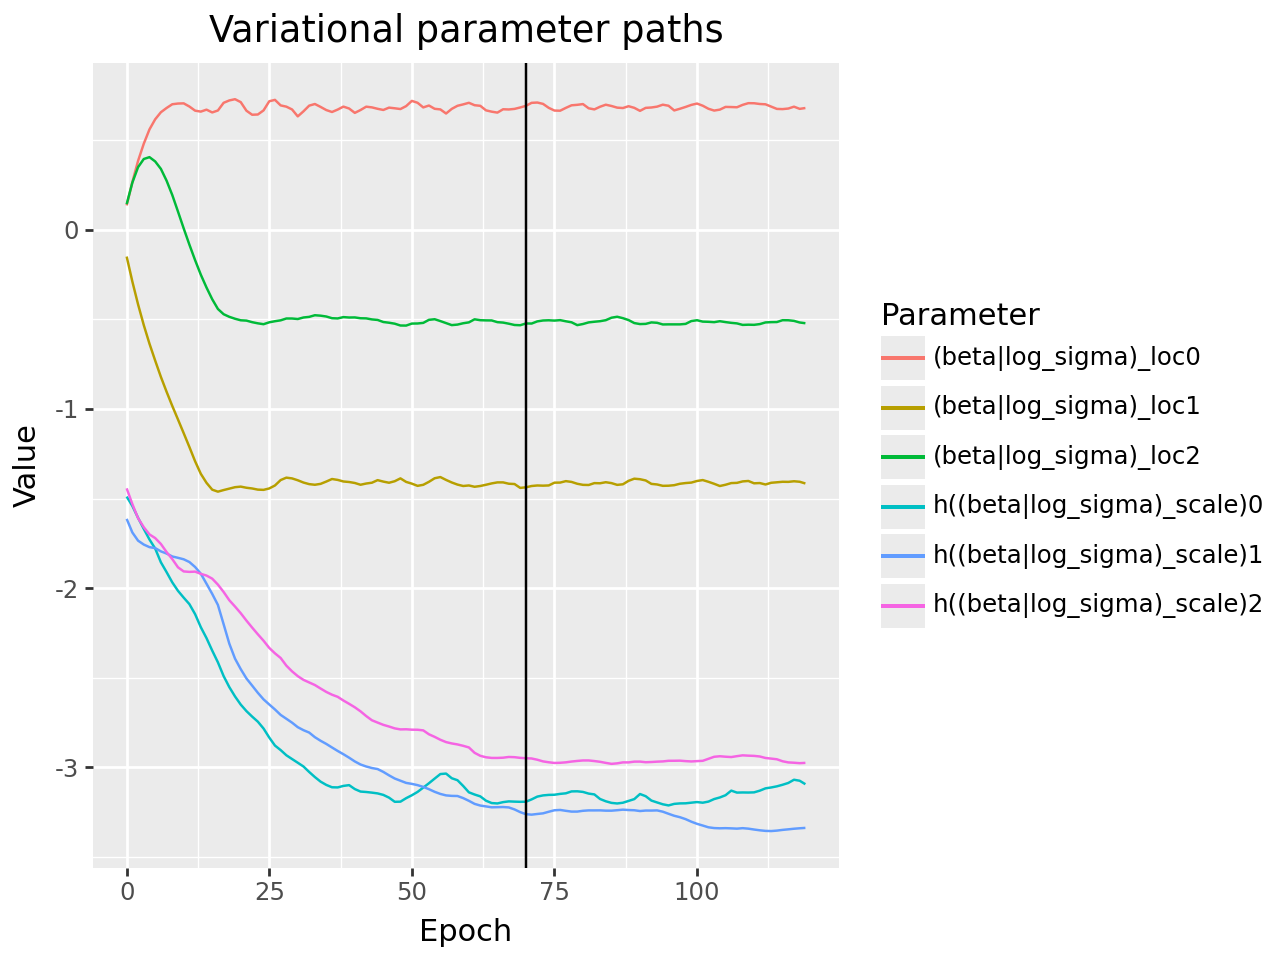

In [26]:
result_mb.plot_params(
    title="Variational parameter paths",
    subset=list(loss_mb.q.parameters),
)

## Held-out predictive check

The interval below describes uncertainty about the conditional mean. It does not include observation noise, so its coverage of held-out responses is not predictive-interval coverage.

In [27]:
X_test = np.asarray(split.test["X"])
y_test = np.asarray(split.test["y"])

mu_test_samples = X_test @ beta_samples.T
posterior_mean = mu_test_samples.mean(axis=1)
interval = np.quantile(mu_test_samples, [0.05, 0.95], axis=1)
rmse = np.sqrt(np.mean((posterior_mean - y_test) ** 2))
coverage = np.mean((y_test >= interval[0]) & (y_test <= interval[1]))

In [28]:
pd.DataFrame(
    {
        "min_monitor_epoch": [result_mb.min_monitor_epoch],
        "n_epochs": [result_mb.n_epochs],
        "test_rmse": [rmse],
        "mean_interval_90pct_coverage": [coverage],
    }
)

,min_monitor_epoch,n_epochs,test_rmse,mean_interval_90pct_coverage
0,70,120,0.535,0.125


In [29]:
x_grid = np.linspace(x.min(), x.max(), 100)
X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
mu_grid_samples = X_grid @ beta_samples.T
mu_grid_mean = mu_grid_samples.mean(axis=1)
mu_grid_interval = np.quantile(mu_grid_samples, [0.05, 0.95], axis=1)
mean_curve = pd.DataFrame(
    {
        "x": x_grid,
        "mean": mu_grid_mean,
        "lower": mu_grid_interval[0],
        "upper": mu_grid_interval[1],
    }
)

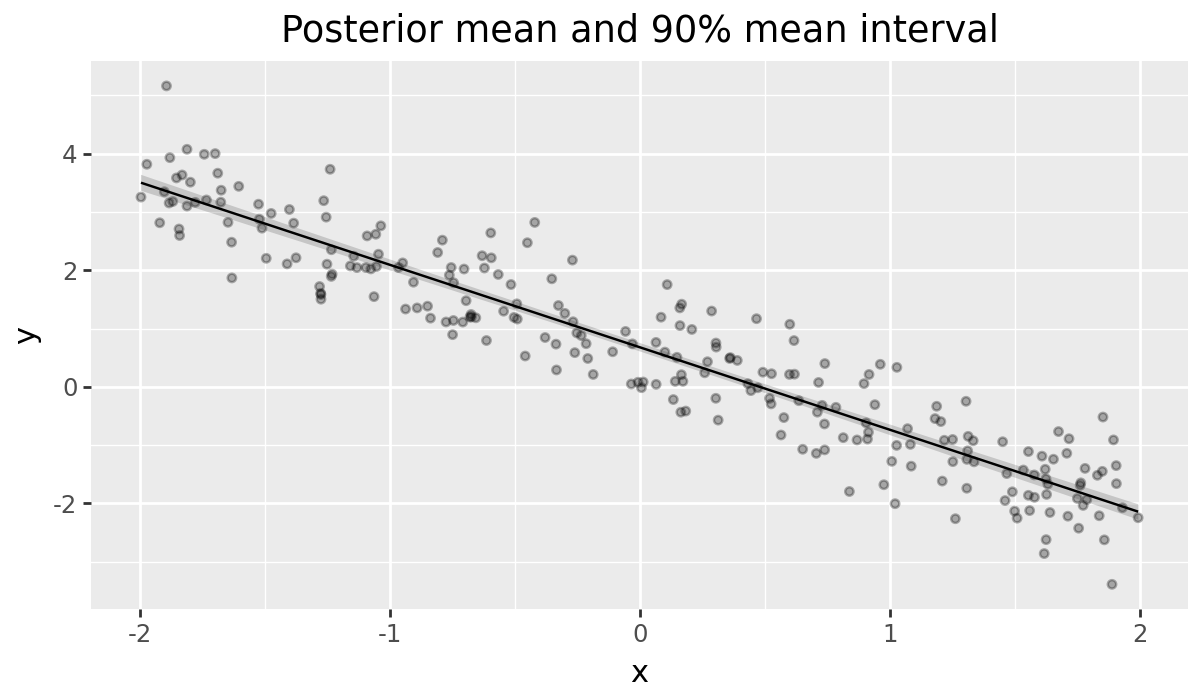

In [30]:
(
    p9.ggplot(data, p9.aes("x", "y"))
    + p9.geom_point(alpha=0.3, size=1.2)
    + p9.geom_ribbon(
        data=mean_curve,
        mapping=p9.aes(x="x", ymin="lower", ymax="upper"),
        inherit_aes=False,
        alpha=0.2,
    )
    + p9.geom_line(data=mean_curve, mapping=p9.aes(y="mean"))
    + p9.labs(title="Posterior mean and 90% mean interval")
    + p9.theme(figure_size=(6, 3.5))
)